**Veri Seti:** Bu çalışmada [Kaggle üzerindeki Türkçe İsimler veri seti](https://www.kaggle.com/datasets/ardaorcun/turkish-names-turkce-isimler) kullanılmıştır.

In [1]:
raw_names = open('turkce_isimler.txt', 'r', encoding='utf-8').read().splitlines()

In [2]:
sorted(raw_names[:10])

['ALİ',
 'BEDRİYE MÜGE',
 'GAMZE',
 'HAYATİ',
 'JALE',
 'KUBİLAY',
 'MAHMUT',
 'MANSUR KÜRŞAD',
 'MİRAÇ',
 'YÜCEL']

In [3]:
words = []

for isim in raw_names:
    parcalar = isim.split()
    words.extend(parcalar)

print(words[:20])
print("Toplam isim:", len(words))


['JALE', 'ALİ', 'MAHMUT', 'MANSUR', 'KÜRŞAD', 'GAMZE', 'MİRAÇ', 'YÜCEL', 'KUBİLAY', 'HAYATİ', 'BEDRİYE', 'MÜGE', 'BİRSEN', 'SERDAL', 'BÜNYAMİN', 'ÖZGÜR', 'FERDİ', 'REYHAN', 'İLHAN', 'GÜLŞAH']
Toplam isim: 2864


## 🛠️ Türkçe Karakter Normalizasyonu

Python'ın standart `lower()` fonksiyonu Türkçe `İ` ve `I` harflerini küçültürken karakter bozulmalarına (örn: `İ` -> `i̇`) yol açar. Bu durum alfabedeki harf sayısını yapay olarak artırarak modelin öğrenmesini zorlaştırır.

Aşağıdaki kod; harf bozulmalarını önlemek için özel bir dönüşüm tablosu uygular, Unicode (NFC) standardı ile karakter yapılarını eşitler, veriyi tekilleştirir (`set`) ve sıralar.

In [4]:
import unicodedata

def normalize_turkish(text):
    # Türkçe büyük-küçük harf dönüşüm tablosu
    dic = {
        'İ': 'i', 'I': 'ı', 'Ş': 'ş', 'Ğ': 'ğ', 'Ü': 'ü', 'Ö': 'ö', 'Ç': 'ç'
    }

    # Karakter tabloda varsa dönüştür, yoksa standart lower() uygula
    text = "".join([dic.get(c, c.lower()) for c in text])

    # Ayrık Unicode karakterlerini (örn: s + nokta) tek bir harfe birleştirir
    text = unicodedata.normalize('NFC', text)

    return text

# İsimleri küçült, tekilleştir (set) ve alfabetik olarak sırala (sorted)
# Burada set() kullanarak tekrar eden isimleri siliyoruz. Böylece veri setindeki kopyaları temizlemiş oluyoruz.
words = sorted(list(set([normalize_turkish(w) for w in words])))

print(f"Hazırlanmış Liste: {words}")



Hazırlanmış Liste: ['abdul', 'abdulaziz', 'abdulkadir', 'abdulkerim', 'abdullah', 'abdullatif', 'abdulmelik', 'abdulsamet', 'abdulselam', 'abdulsemet', 'abdurrahman', 'abdülkadir', 'abdülsamet', 'abide', 'abidin', 'adem', 'adil', 'adnan', 'ahmad', 'ahmet', 'ahmetcan', 'ahsen', 'akber', 'akif', 'aksel', 'akın', 'alaaddin', 'alev', 'alevtina', 'aleyna', 'ali', 'alican', 'alişan', 'almala', 'alp', 'alpaslan', 'alper', 'alperen', 'andaç', 'anıl', 'arda', 'arif', 'arife', 'arman', 'armağan', 'arzu', 'asena', 'asiye', 'aslan', 'aslı', 'aslıhan', 'asudan', 'asuman', 'asım', 'atacan', 'atakan', 'atilla', 'atiye', 'atılgan', 'avni', 'aybegüm', 'aybüke', 'aycan', 'aydemir', 'aydoğan', 'aydın', 'ayhan', 'aykan', 'aykut', 'ayla', 'aylia', 'aylin', 'aysel', 'aysu', 'aysun', 'aytaç', 'ayça', 'ayşe', 'ayşegül', 'ayşen', 'ayşenur', 'azim', 'aziz', 'bahadır', 'bahattin', 'bahri', 'baki', 'bakır', 'bala', 'baran', 'barbaros', 'barış', 'batuhan', 'baturay', 'baver', 'bayram', 'bağbur', 'başak', 'bedreddi

In [5]:
print(f"min: {min(len(w) for w in words)}")
print(f"max:{max(len(w) for w in words)}")

min: 3
max:12


## 🔍 Bigram Mantığı: Zip ile Kayan Pencere (Sliding Window)

Bigram modelinde amacımız, kelime içindeki harflerin ikili kombinasyonlarını (örn: d'den sonra e gelme olasılığı) yakalamaktır.

Bunu sağlamak için kelimenin kendisini ve 1 harf kaydırılmış halini `zip()` fonksiyonu ile eşleştirerek bir **"kayan pencere"** oluştururuz. Böylece döngünün her adımında elimize (Şimdiki Harf, Sonraki Harf) ikilisi gelir.

Bu aşamada model henüz öğrenme yapmaz; sadece veri içindeki ardışık karakter geçişlerini saymaya hazırlanır.

In [6]:
# Test kelimesi üzerinden mantığı simüle edelim
kelime = "deneme"

# Karakter listeleri
chs = list(kelime)
chs_kaymis = chs[1:]

print(f"Orijinal Liste (chs)        : {chs}")
print(f"Kaydırılmış Liste (chs[1:]) : {chs_kaymis}")
print("-" * 40)

# zip() iki listeyi aynı indeksteki elemanlarına göre uç uca eşleştirir.
# Kısa olan liste (chs[1:]) bittiğinde döngü otomatik olarak durur.
for ch1, ch2 in zip(chs, chs[1:]):
    print(f"İkili yakalandı -> Şimdiki harf: {ch1} | Sonraki harf: {ch2}")

Orijinal Liste (chs)        : ['d', 'e', 'n', 'e', 'm', 'e']
Kaydırılmış Liste (chs[1:]) : ['e', 'n', 'e', 'm', 'e']
----------------------------------------
İkili yakalandı -> Şimdiki harf: d | Sonraki harf: e
İkili yakalandı -> Şimdiki harf: e | Sonraki harf: n
İkili yakalandı -> Şimdiki harf: n | Sonraki harf: e
İkili yakalandı -> Şimdiki harf: e | Sonraki harf: m
İkili yakalandı -> Şimdiki harf: m | Sonraki harf: e


In [7]:
b = {}
for w in words:
    # Kelimenin başlangıç ve bitiş sınırlarını belirlemek için özel karakterler ekliyoruz
    chs = ['<S>'] + list(w) + ['<E>']

    for ch1, ch2 in zip(chs, chs[1:]):
        # Sözlük (Dictionary) mekanizmasının arka plandaki çalışma simülasyonu:
        # Başlangıçta: b = {}
        # İşlem anı  : b[('e', 'm')] = b.get(('e', 'm'), 0) + 1  -> (Sözlükte yok, 0 döndü ve 1 eklendi)
        # Sonuç      : b = { ('e', 'm'): 1 }
        bigram = (ch1, ch2)
        # Sözlükte ikili varsa mevcut sayısını getirip 1 artırır, yoksa 0'dan başlatır
        b[bigram] = b.get(bigram, 0) + 1

In [8]:
# Tüm ikili harf kombinasyonlarını frekanslarına (görülme sayılarına) göre büyükten küçüğe sıralar
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 230),
 (('a', 'n'), 143),
 (('e', 'r'), 131),
 (('h', 'a'), 101),
 (('a', '<E>'), 96),
 (('<S>', 's'), 94),
 (('r', '<E>'), 88),
 (('<S>', 'a'), 83),
 (('e', '<E>'), 83),
 (('s', 'e'), 82),
 (('<S>', 'm'), 75),
 (('i', 'n'), 74),
 (('t', '<E>'), 72),
 (('<S>', 'b'), 70),
 (('<S>', 'e'), 69),
 (('l', '<E>'), 67),
 (('m', 'e'), 66),
 (('r', 'a'), 65),
 (('a', 'y'), 64),
 (('m', '<E>'), 60),
 (('e', 'n'), 57),
 (('a', 'l'), 54),
 (('e', 'm'), 53),
 (('u', 'r'), 53),
 (('<S>', 'h'), 52),
 (('<S>', 'n'), 52),
 (('e', 'l'), 51),
 (('a', 'h'), 49),
 (('g', 'ü'), 48),
 (('l', 'a'), 46),
 (('i', 'l'), 46),
 (('<S>', 'g'), 46),
 (('a', 't'), 45),
 (('ü', 'l'), 44),
 (('<S>', 't'), 43),
 (('e', 't'), 42),
 (('d', 'e'), 42),
 (('r', 'i'), 41),
 (('i', '<E>'), 41),
 (('b', 'e'), 40),
 (('n', 'e'), 40),
 (('l', 'i'), 39),
 (('e', 'y'), 39),
 (('k', 'a'), 36),
 (('m', 'a'), 36),
 (('<S>', 'c'), 36),
 (('n', 'a'), 35),
 (('r', 'e'), 34),
 (('<S>', 'f'), 34),
 (('a', 'r'), 33),
 (('s', 

## 🔀 Sözlükten Matrise Geçiş ve Karakter Birleştirme Mantığı

Bir önceki adımda kelimelerin başlangıcını `<S>` (Start) ve bitişini `<E>` (End) olarak iki ayrı özel etiketle takip etmiştik. Ancak bu mantıkla PyTorch üzerinde iki boyutlu bir frekans matrisi (`N`) kurmaya kalkarsak karşımıza matematiksel bir verimsizlik çıkar:

* **Soru:** `<E>` (Bitiş) karakterinden sonra yeni bir harf gelebilir mi? **Hayır.** (O halde matriste `<E>` satırı tamamen sıfırlarla dolu, bomboş bir alan kaplayacaktır).
* **Soru:** Herhangi bir harften sonra tekrar `<S>` (Başlangıç) karakteri gelebilir mi? **Hayır.** (O halde matriste `<S>` sütunu da tamamen sıfır kalacaktır).

### 🛠️ Çözüm: Tek Karakterle İki İş (`.` Karakteri)
Karpathy bu verimsizliği (matrisin gereksiz büyümesini) engellemek için bir kısayol kullanıyor: `<S>` ve `<E>` etiketlerini birleştirip tek bir `.` (nokta) karakterine indirgiyor.

Artık bizim kuracağımız yeni dünyada `.` karakteri:
1. Bir harfin **solundaysa**, o harfin kelime başlangıcı olduğunu,
2. Bir harfin **sağındaysa**, o harften sonra kelimenin bittiğini temsil edecek.

Böylece matrisimizin boyutunu gereksiz yere şişirmemiş ve tek bir karakterle tüm sınır takibini çözmüş oluyoruz.

In [9]:
# Satırlar mevcut harfi (1. karakter), sütunlar ise sonraki harfi (2. karakter) temsil edecek.
# Çok boyutlu dizileri (tensörleri) yüksek performansla işlemek için PyTorch kütüphanesini ekliyoruz.
import torch

## 📊 String Dünyasından Matris Dünyasına Geçiş

Kelime tabanlı sözlükler (`b`) üzerinde yaptığımız frekans sayımlarını, bilgisayarın ve PyTorch'un çok daha hızlı işleyebileceği iki boyutlu bir **Tensör (Matris)** yapısına taşıyoruz. Bu aşamada iki kritik mühendislik adımı atacağız:

1. **Karakter İndeksleme (stoi & itos):** Bilgisayarlar karakterleri doğrudan matris indekslerinde kullanamaz. Bu yüzden alfabedeki her harfe benzersiz bir sayı atayan arama tabloları (`Lookup Tables`) hazırlıyoruz.
2. **Belirteç Birleştirme (`.` Karakteri):** Belleği verimli kullanmak adına `<S>` ve `<E>` etiketlerini tek bir `.` (nokta) karakterinde birleştiriyoruz. `.` artık bizim için hem kelimenin başlangıç hem de bitiş sınırını temsil edecek.

Aşağıdaki kod bloklarında sırasıyla; boş matrisimizi oluşturacak, harfleri sayısallaştıracak ve Türkçe isimlerdeki tüm ikili harf geçişlerini bu matrise işleyeceğiz.

In [10]:
# Türkçe alfabedeki 29 harf + özel '.' karakteri ile toplam 30 karakterimiz var.
# İçi sıfırlarla dolu, 30x30 boyutunda tam sayı (int32) tipinde frekans matrisini oluşturuyoruz.
N = torch.zeros((30, 30), dtype=torch.int32)

In [11]:
# Verideki benzersiz harfleri sırala
chars = sorted(list(set(''.join(words))))

# Harften Sayıya (stoi): 0. indeksi özel '.' karakterine ayırıyoruz
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

# Sayıdan Harfe (itos): Modelin çıktı üretirken kullanacağı ters sözlük
itos = {i: s for s, i in stoi.items()}

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'y': 22,
 'z': 23,
 'ç': 24,
 'ö': 25,
 'ü': 26,
 'ğ': 27,
 'ı': 28,
 'ş': 29,
 '.': 0}

In [12]:
for w in words:
    chs = ['.'] + list(w) + ['.'] # Kelime sınırlarını belirle
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # Şimdiki harfin indeksi
        ix2 = stoi[ch2] # Sonraki harfin indeksi
        N[ix1, ix2] += 1 # Kesişim hücre değerini 1 artır

## 🎨 Isı Haritası (Heatmap) ile Dil İstatistiklerinin Görselleştirilmesi

Oluşturduğumuz iki boyutlu frekans matrisini (`N`), satır ve sütunların kesişimlerini daha rahat okuyabilmek adına görsel bir grafiğe döküyoruz.

Bu grafik sayesinde hangi harften sonra hangi harfin gelme sıklığının yüksek olduğunu çıplak gözle görebileceğiz. Grafikteki **koyu mavi** alanlar frekansı en yüksek olan, yani Türkçe isim fonetiğinde en sık karşılaştığımız harf eşleşmelerini (Bigram) temsil edecek.

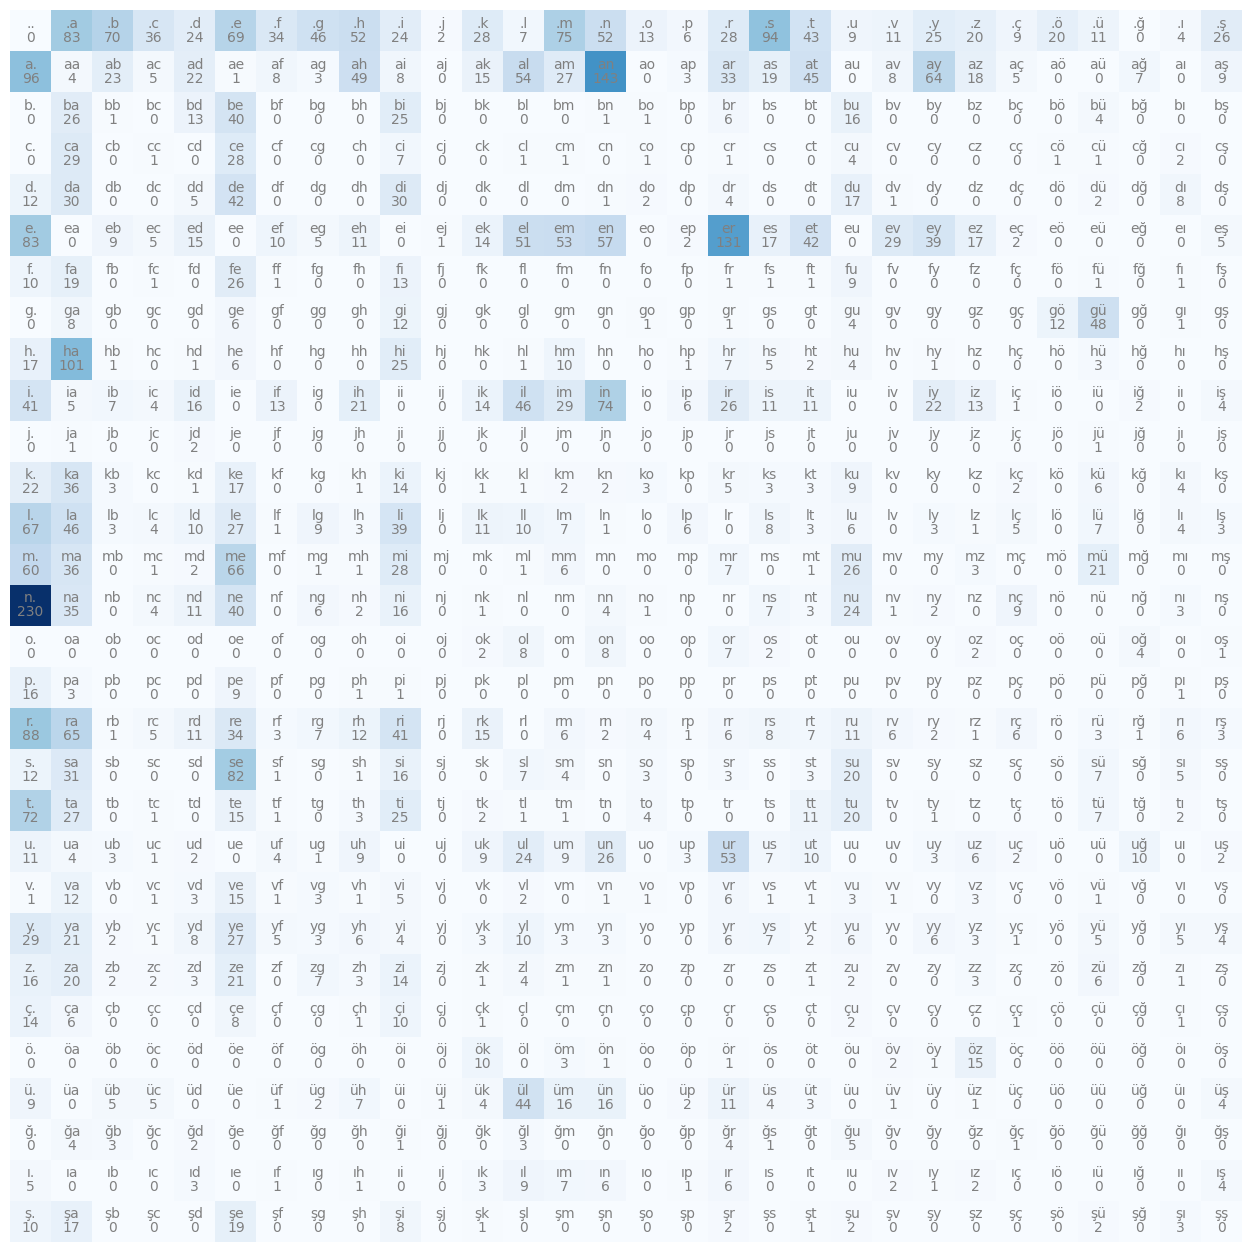

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

# Grafik çizim alanının boyutunu ayarla
plt.figure(figsize=(16, 16))

# Matrisi mavi renk tonlarında bir ısı haritası olarak çiz
plt.imshow(N, cmap='Blues')

# Türkçe alfabedeki toplam karakter sayımız (30x30)
vocab_size = len(stoi)

# Her bir hücrenin içine harf ikilisini ve frekans sayısını yaz
for i in range(vocab_size):
    for j in range(vocab_size):
        # Sayısal indeksleri harfe geri çevir ve birleştir (Örn: 'a' + 'l')
        chstr = itos[i] + itos[j]

        # Hücre içine harf kombinasyonunu yerleştir
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')

        # Hücre içine o kombinasyonun toplam sayısını yaz (.item() ile değer çekilir)
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

# Grafik kenarlarındaki eksen çizgilerini ve koordinat sayılarını gizle
plt.axis('off');

## 🎲 Olasılık Dünyası, Model Örneklemesi ve Broadcasting Gücü

Bu aşamada, topladığımız harf frekanslarını gerçek **olasılık değerlerine** dönüştürüyor ve modelimize ilk Türkçe isim denemelerini yaptırıyoruz. Burada üç kritik matematiksel ve mühendislik kavramıyla karşılaşıyoruz:

### 1. Modelden Örnekleme Alma (`torch.multinomial`)
Modelin tamamen rastgele saçmalamasını istemiyoruz; elindeki olasılık dağılımına göre "zar atmasını" istiyoruz. `torch.multinomial` fonksiyonu, verdiğimiz olasılık vektörüne (`p`) sadık kalarak rastgele seçimler yapar. Örneğin; Türkçe isim başlangıcında `A` harfinin gelme olasılığı `%13` ise, atılan zarların kabaca `%13`'ü `A` indeksini getirecektir.

### 2. Sıfır Olasılık Problemi ve Smoothing (Model Smoothing: `N + 1`)
Eğer veri setimizde `j` harfinden sonra `f` harfi hiç gelmemişse, o hücrenin frekansı `0` olacaktır. Matematiksel olarak olasılık `0` olduğunda, ileride hesaplayacağımız Loss değeri **Eksi Sonsuz (Negative Infinity - `-inf`)** çıkacak ve model patlayacaktır. Bunu engellemek için tüm matrise yapay olarak `1` ekliyoruz (`N + 1`). Buna **Model Smoothing (Yapay Yumuşatma)** denir; böylece hiçbir harf geçişinin ihtimali sıfır olmaz, model "asla imkansız demez".

### 3. PyTorch'un En Güçlü Silahı: Broadcasting Kuralları
Matrisin her satırını kendi satır toplamına bölerek satır bazlı olasılık matrisini (`P`) elde etmek istiyoruz.
* Matrisimizin boyutu: `(30, 30)`
* Satır toplamlarının boyutu: `(30, 1)` -> `keepdims=True` sayesinde sütun boyutunu koruduk.

PyTorch arka planda otomatik olarak `(30, 1)` boyutundaki bu toplam vektörünü yan yana kopyalayarak `(30, 30)` boyutuna genişletir (Broadcast eder) ve matrisi matrise tek hamlede böler. Eğer `keepdims=True` demeseydik, boyut `(30)` olacaktı ve PyTorch bölme işlemini yanlış yönde (sütun bazlı) yaparak modelimizin tüm olasılık matematiğini darmadağın edecekti.

In [14]:
# Kelime başlangıçlarını temsil eden 0. satırı (nokta satırı) çekiyoruz
p = N[0].float()

# Frekansları, toplamlarına bölerek olasılık dağılımına çeviriyoruz
p = p / p.sum()

# Tekrarlanabilir sonuçlar almak için rastgelelik üreticisini (seed) sabitliyoruz
g = torch.Generator().manual_seed(2147483647)

# Olasılık dağılımına (p) göre 1 adet rastgele harf indeksi seçiyoruz
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

# Seçilen indeksi harfe geri çeviriyoruz
print(ix)
itos[ix]

3


'c'

In [15]:
g = torch.Generator().manual_seed(2147483647)

# 3 elemanlı rastgele bir vektör üretip olasılığa dönüştürüyoruz (%60, %30, %10 gibi)
p = torch.rand(3, generator=g)
p = p / p.sum()

# Bu olasılık dağılımına göre modele 100 kez zar attırıp çıktıları gözlemliyoruz
# Çıktıda 0 indeksi en çok, 2 indeksi ise en az görülecektir
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [16]:
# Kadrajı genişletiyoruz: Tüm matris için olasılıkları tek seferde hesaplayacağız.
vocab_size = len(stoi)

# Model Smoothing (N+1): 0 frekanslı hücrelerin ileride -inf (sonsuz) hatası vermesini engelliyoruz
P = (N + 1).float()

# Satır toplamlarını (30, 1) boyutunda tutarak matrisi satır bazlı normalize ediyoruz.
# PyTorch burada (30, 1)'lik vektörü (30, 30) boyutuna otomatik olarak "Broadcast" eder.
P /= P.sum(1, keepdims=True)

# Boyut kontrolü: (30, 30) matris, (30, 1) matrise kusursuz şekilde bölünür
print(f"Olasılık Matrisi Boyutu: {P.shape}")
print(f"Satır Toplamları Boyutu : {P.sum(1, keepdims=True).shape}")

Olasılık Matrisi Boyutu: torch.Size([30, 30])
Satır Toplamları Boyutu : torch.Size([30, 1])


## 🎲 Modelden İlk Türkçe İsim Üretimi (Sampling)

Artık elimizde her harften sonra hangi harfin geleceğini bilen devasa bir olasılık matrisi (`P`) var. Şimdi yapacağımız işlem, modele bir harf verip *"Bana bu satırdaki olasılıklara göre yeni bir harf seç, sonra o seçtiğin harfin satırına geç ve kelime bitene kadar bu zarı atmaya devam et"* demektir.

### 🔄 Sonsuz Döngü (`while True`) Nasıl Çalışıyor?
1. **Başlangıç (`ix = 0`):** Döngüye her zaman `0` indeksiyle, yani `.` (nokta/başlangıç) karakteriyle başlıyoruz.
2. **Satır Seçimi (`p = P[ix]`):** Matristen o anki harfimizin satırını çekiyoruz. Örneğin başlangıçta `.` satırındaki tüm harflerin olasılık dağılımını alıyoruz.
3. **Zar Atışı (`torch.multinomial`):** O satırdaki olasılıklara göre model 1 adet harf seçiyor ve yeni indeksimiz (`ix`) artık o harf oluyor.
4. **Bitiş Koşulu (`if ix == 0`):** Eğer model attığı zar sonucunda tekrar `0` indeksini (yani kelime bitişini temsil eden `.` karakterini) seçerse, `break` komutu devreye giriyor ve kelime tamamlanmış oluyor.

*Not: Model tamamen bizim veri setimizdeki Türkçe harf geçişlerinin istatistiğini taklit ettiği için, ürettiği isimler sözlükte olmasa bile kulağa Türkçe fonetiğine uygun gelecektir.*

In [17]:
# Sonuçların tekrarlanabilir olması için rastgelelik üreticisini sabitliyoruz
g = torch.Generator().manual_seed(2147483647)

# Modelimize 5 adet benzersiz isim ürettiriyoruz
for i in range(5):
    out = []
    ix = 0 # Döngü her zaman '.' (başlangıç) karakteri ile başlar

    while True:
        # Mevcut harfin olasılık satırını matristen çek
        p = P[ix]

        # Bu satırdaki olasılıklara göre bir sonraki harfi seç
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

        # Seçilen harfi çıktı listesine ekle
        out.append(itos[ix])

        # Eğer seçilen harf tekrar '.' (bitiş) ise kelimeyi tamamla ve döngüden çık
        if ix == 0:
            break

    # Üretilen karakter listesini birleştirerek ekrana bas
    print(''.join(out))

casran.
mmusl.
sate.
öerin.
himur.


## 📉 Modelin Başarısını Ölçmek: Likelihood ve NLL Mantığı

Şu ana kadar modele isimler ürettirdik ama elimizde başarısını ölçen tek bir sayısal skor (Loss) yok. Performansı hesaplamak için istatistiksel modellerin kalbi olan **Likelihood (Olabilirlik)** kavramını kullanıyoruz.

### 🎭 Bir Örnekle Likelihood (Olabilirlik)
Veri setimizde sadece üç isim olsun: **"ALİ", "ASLI", "CAN"**. Modelimizin bu isimleri üretme olasılıkları sırasıyla `%10` ($0.10$), `%5` ($0.05$) ve `%2` ($0.02$) olsun.

* **Likelihood:** Bu bağımsız olasılıkların birbiriyle çarpımıdır:
  $$0.10 \times 0.05 \times 0.02 = 0.0001$$
* **Hedef:** Bu değeri maksimuma, yani **1.0**'e ulaştırmaktır. Model gerçek verilere ne kadar yüksek olasılık verirse o kadar başarılıdır.

---

### 🛠️ Karşılaşılan 2 Büyük Sorun ve Çözümü

Binlerce harf geçişini hesaba kattığımızda karşımıza iki büyük mühendislik problemi çıkar:

#### 1. Bellek Taşması (Underflow) Problemi
* **Sorun:** Milyonlarca minik olasılığı ($0.02 \times 0.003 \times 0.01 \dots$) birbiriyle çarptıkça sonuç sıfıra o kadar yaklaşır ki bilgisayarın işlemcisi bu sayıyı taşıyamaz ve doğrudan `0` kabul eder.
* **Çözüm ($\log$ Mucizesi):** Logaritma, bu imkansız çarpma işlemlerini kolay bir **toplama** işlemine dönüştürür ve taşmayı önler:
  $$\log(a \times b \times c) = \log(a) + \log(b) + \log(c)$$

#### 2. Minimizasyon ve Negatif Sayı Problemi
* **Sorun:** Olasılık değerleri her zaman $0$ ile $1$ arasında olduğundan, logaritmaları her zaman **negatif** çıkar (Örn: $\log(0.10) \approx -2.30$). Ancak yapay zekadaki optimizasyon algoritmaları (Gradient Descent) negatif bir değeri büyütmek üzere değil, pozitif bir hatayı **minimize etmek (azaltmak)** üzere tasarlanmıştır.
* **Çözüm (Negatif Log-Likelihood - NLL):** Negatif çıkan sonucun başına bir eksi (`-`) daha koyarak değeri pozitife çeviririz.



---

### 🎯 Özetle Nihai Hedefimiz
Modelin hatasını temsil eden **ortalama Negatif Log-Likelihood (NLL)** değerini sıfıra (`0`) en yakın seviyeye indirmektir.

* **Düşük Loss (0'a yakın):** Yüksek başarı, doğru Türkçe tahminleri.
* **Yüksek Loss:** Başarısız model, rastgele saçmalama.

In [18]:
# HEDEFİMİZ: Model parametrelerine göre verinin "Likelihood" (olabilirlik) değerini maksimuma çıkarmak.
# -> Bu işlem, matematiksel olarak "Log-Likelihood" değerini maksimuma çıkarmakla eşdeğerdir (çünkü log monotondur).
# -> Log-Likelihood'u maksimum yapmak, "Negatif Log-Likelihood" (NLL) değerini minimize etmek (en aşağı çekmek) demektir.
# -> En nihayetinde hedefimiz, tüm veri setindeki ortalama Negatif Log-Likelihood değerini en küçük hale getirmektir.

# Matematiksel Kural: Çarpım halindeki olasılıkları, bilgisayar belleğinde taşma yapmaması için logaritma ile toplama çeviriyoruz.
# log(a * b * c) = log(a) + log(b) + log(c)

## 🧮 Döngü ile Toplam Veri Seti Loss (NLL) Hesaplaması

Teoride tartıştığımız tüm matematiksel adımları artık kod dökümüne geçiriyoruz. Veri setindeki tüm kelimeleri (`words`) tek tek tarayarak her bir harf geçişinin (Bigram) olasılığını çekecek, logaritmasını alacak ve bunları toplayarak modelimizin nihai başarı skorunu (`Loss`) hesaplayacağız.

In [19]:
log_likelihood = 0.0
n = 0  # Toplam harf ikilisi (bigram) sayacı

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        # Olasılık matrisinden ilgili harf geçişinin ihtimalini çek
        prob = P[ix1, ix2]

        # Olasılığın logaritmasını al (Çarpma krizini toplamaya çevirmek için)
        logprob = torch.log(prob)

        # Log-likelihood değerlerini üst üste topla
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')

# Negatif Log-Likelihood (NLL): Sonucu pozitife çevirerek hataya (Loss) dönüştür
nll = -log_likelihood
print(f'{nll=}')

# Ortalama Loss (Kayıp) Değeri: Toplam hatayı harf sayısına bölerek normalize et
print(f'Ortalama Loss: {nll/n}')

log_likelihood=tensor(-14759.0654)
nll=tensor(14759.0654)
Ortalama Loss: 2.434685707092285


## 🧠 Yapay Sinir Ağları İçin Eğitim Setinin (X, Y) Hazırlanması

Şu ana kadar tüm olasılıkları matrise direkt saydırarak manuel bir sayım gerçekleştirdik. Karpathy bu adımda bizi yapay sinir ağlarına (Neural Networks) hazırlamak için veriyi **Girdi ($X$)** ve **Hedef/Etiket ($Y$)** olarak ikiye ayırıyor.

### 🎯 Girdi ve Etiket Mantığı (Supervised Learning)
Modelin bir sonraki harfi tahmin edebilmeyi öğrenmesi için ona örüntüler sunmalıyız:
* **$X$ (Girdi/Feature):** Modele verdiğimiz mevcut harf.
* **$Y$ (Hedef/Label):** Modelden tahmin etmesini beklediğimiz, o harften hemen sonra gelen harf.



Örneğin ilk kelimemizdeki `.` ve `a` geçişinde; girdi `.` ($0$), modelin tahmin etmesi gereken hedef ise `a` ($1$) olacaktır. Bu sayede modelimizi Gradient Descent ile eğitebileceğimiz standart bir denetimli öğrenme yapısı kurmuş oluyoruz.

In [20]:
# Bigram modelini eğitmek için girdi (xs) ve hedef (ys) listelerini oluşturuyoruz
xs, ys = [], []

# Şimdilik mantığı görmek için sadece ilk kelimeyi (:1) inceliyoruz
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]  # Girdi harfinin sayısal indeksi (X)
        ix2 = stoi[ch2]  # Hedef harfin sayısal indeksi (Y)

        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

# Listeleri PyTorch tensörlerine dönüştürüyoruz (Modelin işleyebileceği format)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a b
b d
d u
u l
l .


In [21]:
xs

tensor([ 0,  1,  2,  4, 20, 12])

In [22]:
ys

tensor([ 1,  2,  4, 20, 12,  0])

## ⚡ Nöral Ağ Yapısı: One-Hot Encoding, Logits ve Softmax Dönüşümü

Bu aşamada, olasılık matrisini manuel doldurmayı bırakıp ilk **Yapay Sinir Ağı (Single-layer Neural Network)** katmanımızı kuruyoruz. Ağın girdi alıp olasılık üretmesi için sırasıyla şu matematiksel dönüşümleri gerçekleştiriyoruz:

### 1. Sayısal İndeksleri Vektöre Çevirmek (`One-Hot Encoding`)
Nöral ağlar `5` veya `13` gibi tam sayıları (indeksleri) girdi olarak aldığında bunlara sayısal bir büyüklük anlamı yükleyebilir (yani 13 > 5 gibi). Harflerin birbirine üstünlüğü olmadığı için her harfi bağımsız birer vektöre çeviririz. `F.one_hot` fonksiyonu, ilgili harfin indeksini `1`, kalan tüm hücreleri `0` yapar.

### 2. Ağırlık Matrisi ($W$) ve Logit Kavramı
Girdimizi rastgele değerlerle başlattığımız ağırlık matrisiyle ($W$) çarpıyoruz: `logits = xenc @ W`. Çarpım sonucu elde ettiğimiz bu ham, pozitif ve negatif değerlerden oluşan sayılara **Logits (Ham Çıktılar)** denir. Bunlar modelin arka plandaki "tahmin log-sayımlarıdır".

### 3. Logits'ten Olasılığa Geçiş (Matematiksel Softmax)
Ham çıktıları (logits) doğrudan olasılık olarak kullanamayız çünkü negatif olasılık olamaz ve toplamları 1'e eşit değildir. Bu krizi **Softmax** formülüyle çözeriz:
1. **Üstel Fonksiyon (`.exp()`):** Tüm negatif değerleri pozitife çevirir ve yüksek olan ham çıktıların payını büyüterek ödüllendirir (`counts`).
2. **Normalizasyon (`counts / sum`):** Her hücreyi kendi satır toplamına bölerek değerlerin $0$ ile $1$ arasına sıkışmasını ve satır toplamının tam **1.0** (yani meşru birer olasılık) olmasını sağlar.

In [23]:
import torch.nn.functional as F

vocab_size = len(stoi)

# İndeks halindeki girdileri (xs), ağın işleyebileceği one-hot vektörlerine çeviriyoruz
xenc = F.one_hot(xs, num_classes=vocab_size).float()

print(f"Girdi Matrisi Boyutu: {xenc.shape}") # Örn: (6, 30) -> 6 harf için 30 boyutlu vektörler

Girdi Matrisi Boyutu: torch.Size([6, 30])


In [24]:
# Rastgele ağırlıklardan oluşan matrisi başlatıyoruz (Girdi Boyutu, Çıktı Boyutu)
W = torch.randn((vocab_size, vocab_size))

# Logits: One-hot matrisi ile ağırlık matrisini çarparak ham tahmin skorlarını elde ediyoruz
logits = xenc @ W

# Üstel fonksiyon (Exponential) uygulayarak tüm negatif skorları pozitif sayımlara çeviriyoruz
counts = logits.exp()

# Softmax Normalizasyonu: Satır toplamlarına bölerek meşru olasılıklar (0-1 arası) üretiyoruz
probs = counts / counts.sum(1, keepdims=True)

In [25]:
# İlk harfin ürettiği 30 elemanlı olasılık dağılımını kontrol et
print(f"İlk harf çıktı olasılıkları:\n{probs[0]}")
print(f"Vektör Boyutu: {probs[0].shape}")

# Olasılık kuralları gereği satır toplamının 1.0 olduğunu doğrula
print(f"Olasılıklar Toplamı: {probs[0].sum().item()}")

İlk harf çıktı olasılıkları:
tensor([0.0755, 0.0549, 0.0566, 0.0871, 0.0144, 0.0321, 0.0388, 0.0229, 0.0958,
        0.0208, 0.0538, 0.0904, 0.0481, 0.0036, 0.0395, 0.0327, 0.0145, 0.0585,
        0.0074, 0.0252, 0.0117, 0.0077, 0.0039, 0.0106, 0.0148, 0.0285, 0.0135,
        0.0200, 0.0118, 0.0049])
Vektör Boyutu: torch.Size([30])
Olasılıklar Toplamı: 0.9999998807907104


## 🧱 Özet: Tek Katmanlı Nöral Ağın İleri Besleme (Forward Pass) Döngüsü

Şu ana kadar adım adım işlediğimiz tüm süreci tek bir hücrede birleştiriyoruz. Bu kod bloğu, geleneksel sayma tabanlı Bigram modelinin yaptığı işi (harf olasılıklarını tahmin etme), yapay sinir ağları dünyasındaki doğrusal bir katman (`Linear Layer`) ve bir aktivasyon fonksiyonu (`Softmax`) ile birebir simüle eder.

### 🔄 Adım Adım İşlem Akışı:
1. **Girdi ($X$):** Harf indeksleri önce `One-Hot Encoding` ile nöral ağın anlayacağı vektör formuna getirilir.
2. **Ağırlıklar ($W$):** Rastgele değerlerle başlatılan ağırlık matrisi, ağın "öğrenebilir" parametreleridir.
3. **Logits ($X \cdot W$):** Vektörler ile ağırlıklar matris çarpımına sokularak ham tahmin skorları üretilir.
4. **Softmax:** Son iki satır (`.exp()` ve normalizasyon) birleşerek literatürdeki **Softmax** aktivasyon fonksiyonunu oluşturur ve ham skorları meşru birer olasılık dağılımına çevirir.

In [26]:
vocab_size = len(stoi)

# 1. Eğitim setimizi doğruluyoruz (Girdiler ve Hedefler)

# 2. Rastgele ağırlık matrisini (W) başlatıyoruz
# Her bir nöral hücre alfabedeki tüm karakter sayısı kadar (30) girdi alır
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g)

# 3. İLERİ BESLEME (FORWARD PASS)
xenc = F.one_hot(xs, num_classes=vocab_size).float()  # İndeksleri One-Hot vektörlerine çevir
logits = xenc @ W                                     # Matris çarpımı ile ham tahmin skorlarını (Logits) üret
counts = logits.exp()                                 # Skorları pozitif sayımlara dönüştür
probs = counts / counts.sum(1, keepdims=True)         # Satır bazlı normalize ederek olasılıkları hesapla (Softmax)

# Çıktı matrisinin boyutunu kontrol et: [Harf Sayısı, Alfabe Boyutu]
print(f"Olasılık Matrisi Boyutu: {probs.shape}")

Olasılık Matrisi Boyutu: torch.Size([6, 30])


## 🔍 Nöral Ağ Çıktılarının Adım Adım Analizi ve Loss Hesabı

Rastgele ağırlıklarla başlatılan nöral ağımızın, eğitim setindeki ilk kelime için nasıl tahminler yaptığını ve ne kadar çuvalladığını adım adım inceliyoruz.

### 🛠️ Döngü İçinde Dönen Mekanizma:
1. **Doğru Olasılığı Seçmek (`p = probs[i, y]`):** Ağımız her harf için alfabedeki tüm karakterlere ait birer olasılık vektörü üretir. Biz bu vektörün içinden sadece **gerçekte gelmesi gereken harfin (`y`)** olasılığını çekeriz.
2. **Kayıp Skorunun Çıkarılması (NLL):** Ağ henüz eğitilmediği için doğru harflere çok düşük olasılıklar (örn: `%1.2`, `%1.8`) verecektir. Bu düşük olasılıkların negatif logaritmasını alarak her adım için birer ceza puanı (NLL) hesaplarız.
3. **Nihai Amaç (Ortalama Loss):** Tüm harf ikililerinden elde ettiğimiz bu ceza puanlarının ortalamasını (`.mean()`) alırız. Nöral ağımızın eğitim boyunca tek hedefi, geriye yayılım (backpropagation) kullanarak bu ortalama Loss değerini olabildiğince aşağı çekmektir.

In [27]:
nlls = torch.zeros(5)  # Her harf ikilisinin ceza puanını tutacak boş vektör

for i in range(5):
    x = xs[i].item()  # Girdi harfinin indeksi
    y = ys[i].item()  # Doğru hedef harfin indeksi

    print('--------')
    print(f'Örnek {i+1}: {itos[x]}{itos[y]} (İndeksler {x},{y})')
    print('Ağa giren karakter:', x)
    print('Ağın ürettiği tüm olasılıklar:', probs[i])
    print('Tahmin edilmesi gereken doğru harf:', y)

    # 1. Ağın doğru harfe verdiği olasılık payını cımbızla çekiyoruz
    p = probs[i, y]
    print('Ağın doğru harfe verdiği olasılık:', p.item())

    # 2. Olasılığın logaritmasını alıp negatife çevirerek ceza skorunu (NLL) buluyoruz
    logp = torch.log(p)
    nll = -logp
    print('Negatif Log-Likelihood (Hata Skoru):', nll.item())

    nlls[i] = nll

print('=========')
# 3. Tüm adımlardaki hataların ortalamasını alarak toplam "Loss" değerimizi buluyoruz
print('Ortalama Hata (Loss) =', nlls.mean().item())

--------
Örnek 1: .a (İndeksler 0,1)
Ağa giren karakter: 0
Ağın ürettiği tüm olasılıklar: tensor([0.0591, 0.0097, 0.0120, 0.0041, 0.0164, 0.0120, 0.0026, 0.0226, 0.0133,
        0.0304, 0.0077, 0.0271, 0.0089, 0.0080, 0.0486, 0.2315, 0.0587, 0.0024,
        0.0242, 0.0053, 0.0330, 0.0106, 0.0028, 0.0193, 0.0115, 0.1496, 0.1420,
        0.0063, 0.0036, 0.0167])
Tahmin edilmesi gereken doğru harf: 1
Ağın doğru harfe verdiği olasılık: 0.009716732427477837
Negatif Log-Likelihood (Hata Skoru): 4.63390588760376
--------
Örnek 2: ab (İndeksler 1,2)
Ağa giren karakter: 1
Ağın ürettiği tüm olasılıklar: tensor([0.0091, 0.0553, 0.0281, 0.0989, 0.0120, 0.0114, 0.0044, 0.0934, 0.0078,
        0.0901, 0.0102, 0.0212, 0.0189, 0.0372, 0.0071, 0.0820, 0.0485, 0.0422,
        0.0282, 0.0047, 0.0300, 0.0596, 0.0459, 0.0083, 0.0309, 0.0098, 0.0390,
        0.0429, 0.0107, 0.0122])
Tahmin edilmesi gereken doğru harf: 2
Ağın doğru harfe verdiği olasılık: 0.02809833735227585
Negatif Log-Likelihood (Hata Skor

## 📉 Nöral Ağın Öğrenme Döngüsü: İleri Besleme, Geriye Yayılım ve Optimizasyon

Bu hücrede, yapay sinir ağlarının temelini oluşturan o meşhur üç adımlı eğitim döngüsünü (Forward, Backward, Update) ilk kez hayata geçiriyoruz.

### 🎯 Karpathy'nin Vektörize Loss Hilesi (`torch.arange`)
Daha önce döngü (`for`) kullanarak tek tek cımbızla çektiğimiz doğru harf olasılıklarını, burada PyTorch'un indeksleme gücüyle tek satırda yapıyoruz: `probs[torch.arange(num_examples), ys]`.
Bu ifade; `0.` satırdan `ys[0]`'ı, `1.` satırdan `ys[1]`'ı çek diyerek tüm doğru olasılıkları bir vektör olarak alır, logaritmasını hesaplar ve ortalamasını (`.mean()`) çıkarır.

### 🔄 Optimizasyonun 3 Altın Adımı
1. **`W.requires_grad = True`:** PyTorch'a *"Bu ağırlık matrisine göre türev alacağız, her adımı hafızanda takip et"* talimatı veriyoruz.
2. **`loss.backward()`:** Geriye yayılım (Backpropagation) mekanizması çalışır. Loss değerini düşürmek için hangi ağırlığın ne yönde ($+$ veya $-$) değiştirilmesi gerektiği hesaplanır ve `W.grad` içine yazılır.
3. **`W.data += -0.1 * W.grad`:** Gradyan İnişi (Gradient Descent) adımıdır. Ağırlıkları, hata payının tersi yönünde minik bir öğrenme oranı (`0.1` / Learning Rate) ile güncelleyerek modelin hatasını azaltırız.

In [28]:
vocab_size = len(stoi)
num_examples = xs.nelement() # Toplam örnek sayısı

# 1. Ağırlıkları rastgele başlat ve türev takibini (requires_grad) aktif et
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

# --- İLERİ BESLEME (FORWARD PASS) ---
xenc = F.one_hot(xs, num_classes=vocab_size).float() # Girdileri One-Hot vektörüne çevir
logits = xenc @ W                                    # Ham tahmin skorlarını (Logits) üret
counts = logits.exp()                                # Negatif sayıları sıfırla/pozitife çevir
probs = counts / counts.sum(1, keepdims=True)        # Olasılık dağılımını elde et (Softmax)

# İndeks hilesi ile doğru harf olasılıklarını seç, logaritmasını al ve ortalama Loss'u bul
loss = -probs[torch.arange(num_examples), ys].log().mean()
print("İlk Adım Loss Değeri:", loss.item())

# --- GERİYE YAYILIM (BACKWARD PASS) ---
W.grad = None   # Eski adımdan kalan gradyanları sıfırla (PyTorch üst üste toplar)
loss.backward() # Tüm ağırlıkların hata üzerindeki etkisini (türevini) hesapla

# --- PARAMETRE GÜNCELLEME (OPTIMIZATION) ---
# Öğrenme oranı (Learning Rate = 0.1) ile ağırlıkları hatayı azaltacak yönde güncelle
W.data += -0.1 * W.grad

İlk Adım Loss Değeri: 3.9849777221679688


## 🚀 Gerçek Ölçekli Optimizasyon ve L2 Düzenlileştirme (Regularization)

Bu hücrede, veri setimizin tamamını  nöral ağımıza besliyor ve modeli gerçek anlamda eğitmeye başlıyoruz.
### 1. Neden Öğrenme Oranını (Learning Rate) 50 Yaptık?
Tek katmanlı doğrusal ağlarda (Linear Layer) kayıp yüzeyi çok pürüzsüzdür ve ağırlıklar başlangıçta sıfıra çok yakın olduğundan, modeli hızla doğru yöne fırlatmak için büyük bir öğrenme oranına ihtiyaç duyarız.

### Modelin Aşırı Güvenini Kırmak: L2 Regularization (`+ 0.01 * (W**2).mean()`)
Loss fonksiyonunun sonuna eklenen bu terim, ağımızın ağırlıklarını (`W`) sürekli sıfıra doğru çekmeye çalışan yapay bir yerçekimi gibidir:
* **Amaç:** Eğer bu terimi eklemezsek, model bazı harf geçişlerinden "aşırı emin" olmak için ağırlıkları sonsuza kadar büyütebilir.
* **Etki:** Ağırlıkların karesini alıp loss değerine ekleyerek ağa şu mesajı veririz: *"Hatanı minimize et ama bunu yaparken ağırlık matrisini gereksiz yere şişirme, her harfe biraz da olsa açık kapı bırak (Smoothing)."* Bu durum, geleneksel modeldeki `N + 1` hilesinin nöral ağlar dünyasındaki tam matematiksel karşılığıdır.



In [29]:
# 1. Tüm veri seti üzerinden eğitim setini (X, Y) inşa ediyoruz
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('Toplam Örnek Sayısı: ', num)

# 2. Ağ parametrelerini (W) Türkçe alfabe boyutuna (30x30) göre başlat
vocab_size = len(stoi)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

# 3. GRADYAN İNİŞİ DÖNGÜSÜ (Eğitim Adımı)
for k in range(100):

  # --- İLERİ BESLEME (FORWARD PASS) ---
  xenc = F.one_hot(xs, num_classes=vocab_size).float() # Girdileri One-Hot vektörüne çevir
  logits = xenc @ W                                    # Ham tahmin skorlarını (Logits) üret
  counts = logits.exp()                                # Skorları pozitif sayımlara dönüştür
  probs = counts / counts.sum(1, keepdims=True)        # Olasılıkları hesapla (Softmax)

  # Ana Loss değerine, ağırlıkların büyümesini engelleyen L2 Regularization (Ceza Terimi) ekliyoruz
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
  print(f"Adım {k}: Loss = {loss.item()}")

  # --- GERİYE YAYILIM (BACKWARD PASS) ---
  W.grad = None   # Gradyanları sıfırla
  loss.backward() # Türevleri hesapla

  # --- GÜNCELLEME (UPDATE) ---
  W.data += -50 * W.grad

Toplam Örnek Sayısı:  6062
Adım 0: Loss = 4.004208087921143
Adım 1: Loss = 3.5598607063293457
Adım 2: Loss = 3.281027317047119
Adım 3: Loss = 3.1113791465759277
Adım 4: Loss = 2.9964005947113037
Adım 5: Loss = 2.9119222164154053
Adım 6: Loss = 2.848100185394287
Adım 7: Loss = 2.7984607219696045
Adım 8: Loss = 2.758578300476074
Adım 9: Loss = 2.725668430328369
Adım 10: Loss = 2.697981357574463
Adım 11: Loss = 2.674344062805176
Adım 12: Loss = 2.653918743133545
Adım 13: Loss = 2.636084794998169
Adım 14: Loss = 2.6203744411468506
Adım 15: Loss = 2.6064324378967285
Adım 16: Loss = 2.5939838886260986
Adım 17: Loss = 2.5828137397766113
Adım 18: Loss = 2.572746992111206
Adım 19: Loss = 2.5636391639709473
Adım 20: Loss = 2.5553696155548096
Adım 21: Loss = 2.5478339195251465
Adım 22: Loss = 2.5409433841705322
Adım 23: Loss = 2.5346221923828125
Adım 24: Loss = 2.5288050174713135
Adım 25: Loss = 2.5234360694885254
Adım 26: Loss = 2.518468141555786
Adım 27: Loss = 2.513859272003174
Adım 28: Loss =

## 🎲 Eğitilmiş Nöral Ağ Modeli ile Yeni İsim Üretimi (Sampling)

Bigram serüvenimizin son adımında, tamamen rastgele sayılardan alıp geriye yayılım (backpropagation) ile eğittiğimiz **ağırlık matrisini (`W`)** kullanarak yeni Türkçe isimler türetiyoruz.

### 🔄 Eski Yöntem (Matris) vs Yeni Yöntem (Nöral Ağ)
* **Eski Yapı (`p = P[ix]`):** Harf indeksini verip, önceden elle hesaplanmış olasılık tablosundan o satırı direkt çekiyorduk.
* **Yeni Yapı (Nöral Ağ):** Döngü içindeki o anki harf indeksini alıp anlık olarak `One-Hot` vektörüne çeviriyor, ağırlık matrisiyle çarpıyor ve `Softmax` katmanından geçirerek **canlı canlı** bir olasılık dağılımı (`p`) ürettiriyoruz.

Modelimiz artık sadece verileri sayan bir tablo değil; girdiyi işleyip mantıklı çıktılar üreten yaşayan, dinamik tek katmanlı bir yapay sinir ağıdır!

In [30]:
vocab_size = len(stoi)
g = torch.Generator().manual_seed(2147483647)

# Modelimize eğittiği yeni ağırlıklarla 5 adet isim ürettiriyoruz
for i in range(5):
    out = []
    ix = 0  # Döngü her zaman '.' (başlangıç) karakteriyle başlar

    while True:
        # 1. Mevcut harf indeksini tek elemanlı bir tensöre çevirip One-Hot formatına al
        xenc = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()

        # 2. İLERİ BESLEME (FORWARD PASS): Anlık harf için olasılık dağılımını canlı hesapla
        logits = xenc @ W      # Ham tahmin skorları
        counts = logits.exp()  # Skorları pozitife çevir
        p = counts / counts.sum(1, keepdims=True)  # Canlı olasılık dağılımı (Softmax)

        # 3. Üretilen canlı olasılığa göre zar at ve sonraki harfi seç
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])

        # Eğer model tekrar '.' (bitiş) karakterini seçerse kelimeyi tamamla
        if ix == 0:
            break
    print(''.join(out))

case.
hammusl.
sate.
öerin.
himur.
